Dimensões RGB: (512, 512, 3)


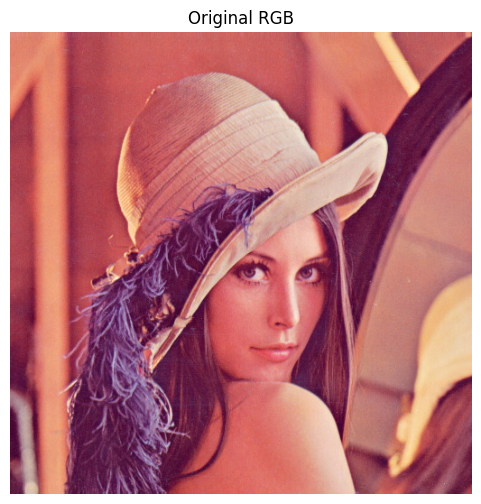

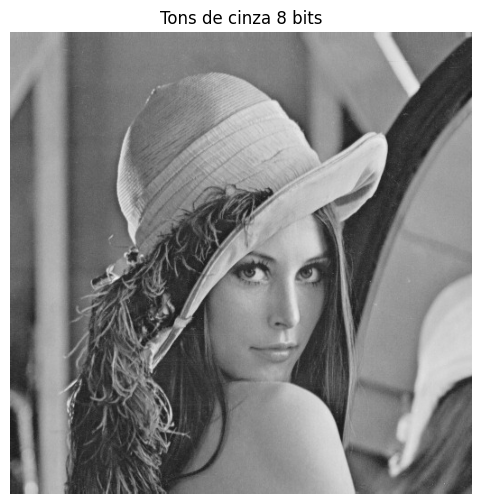

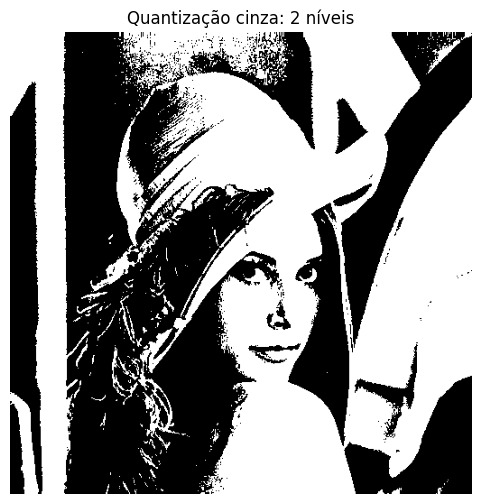

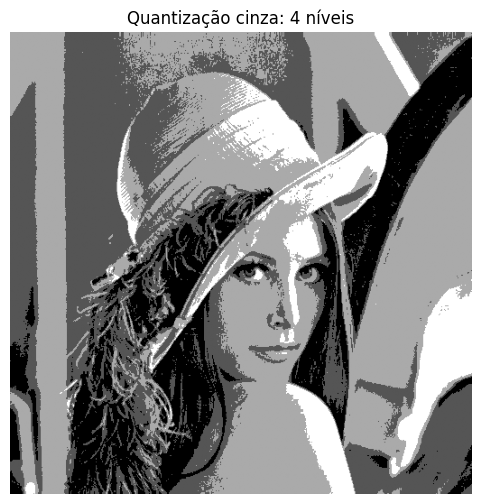

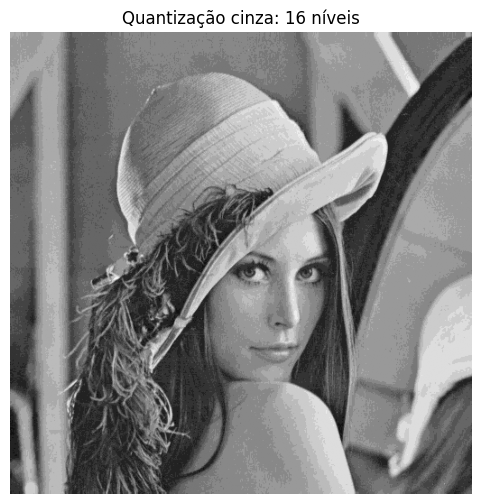

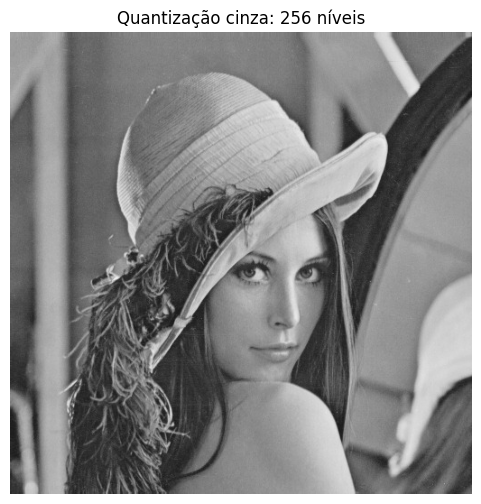

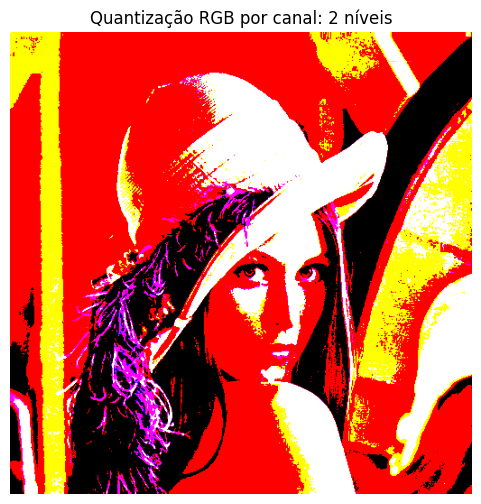

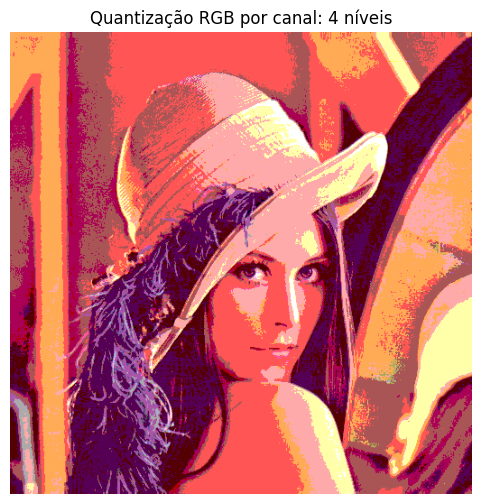

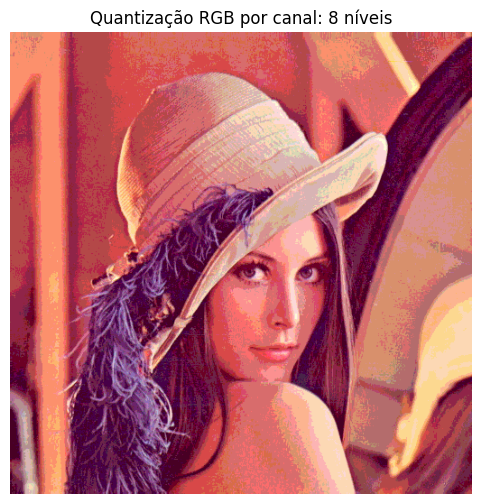

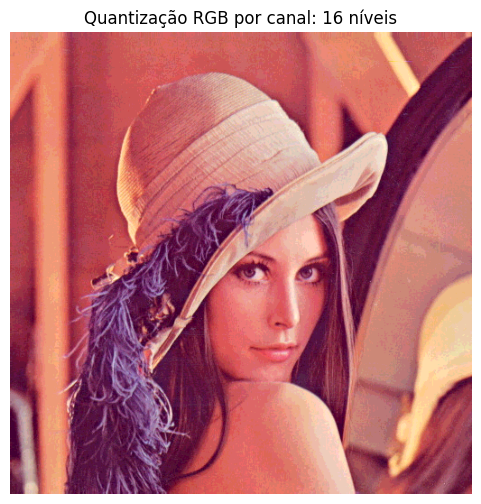

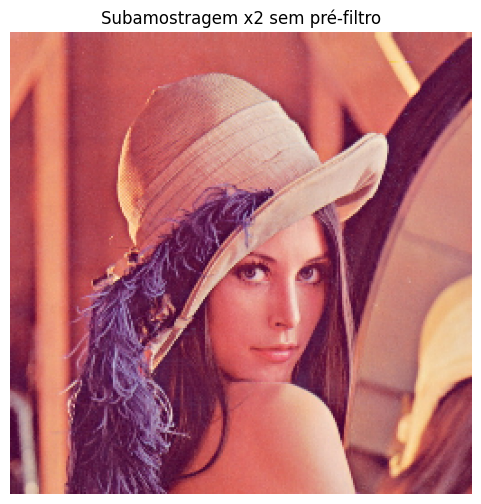

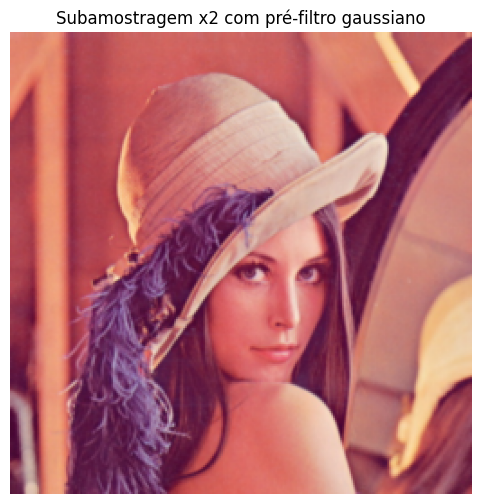

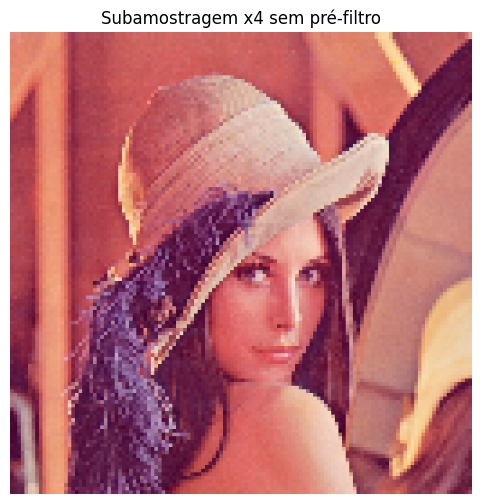

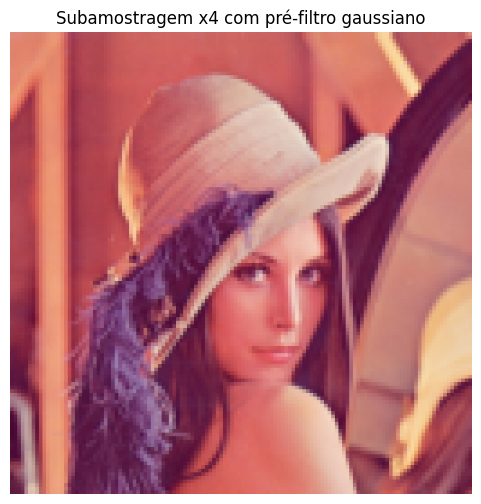

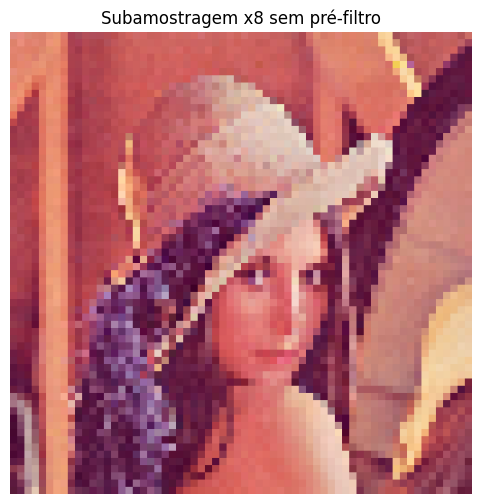

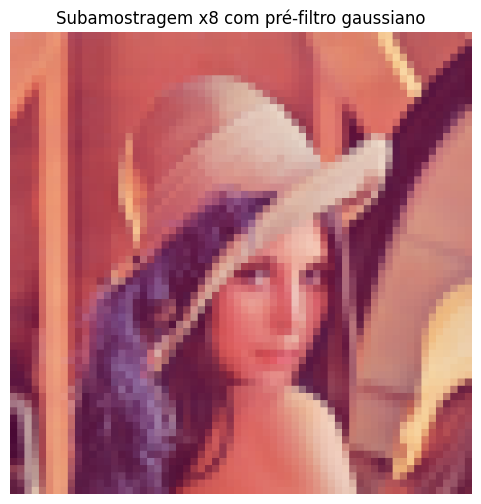

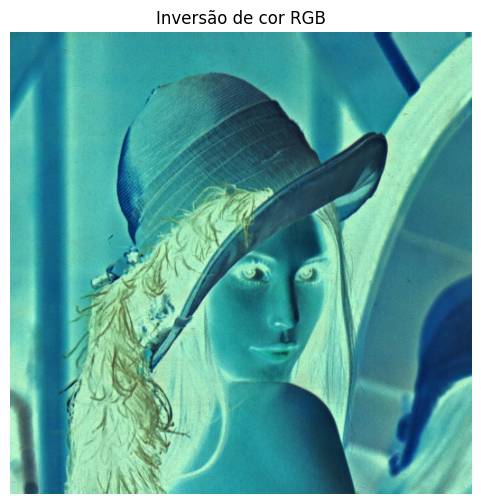

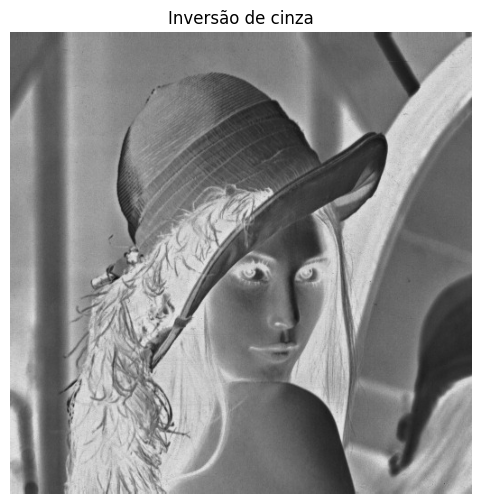

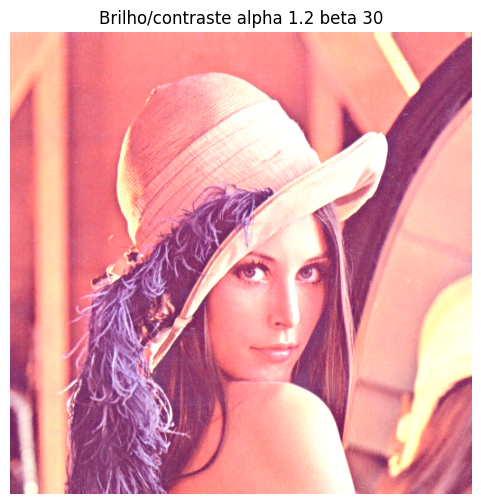

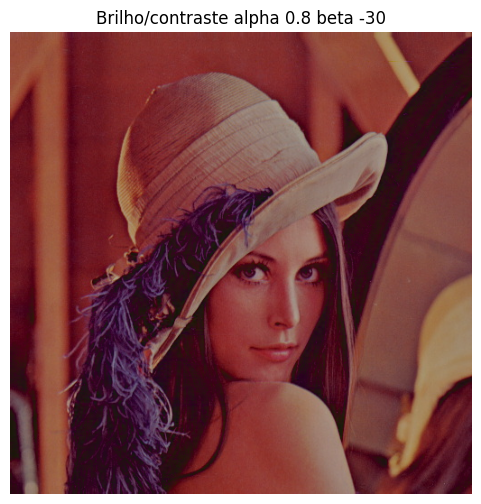

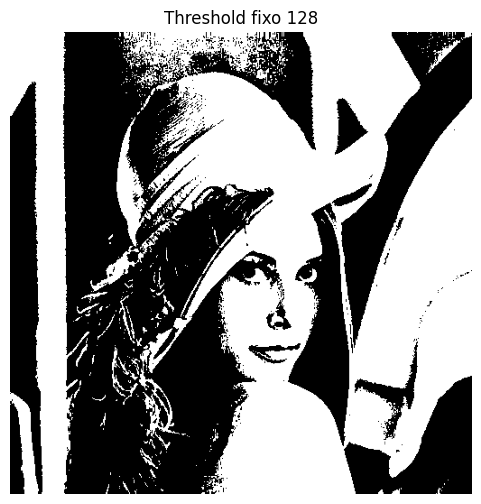

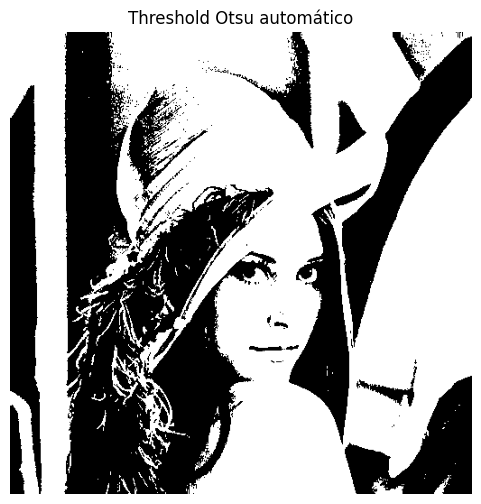

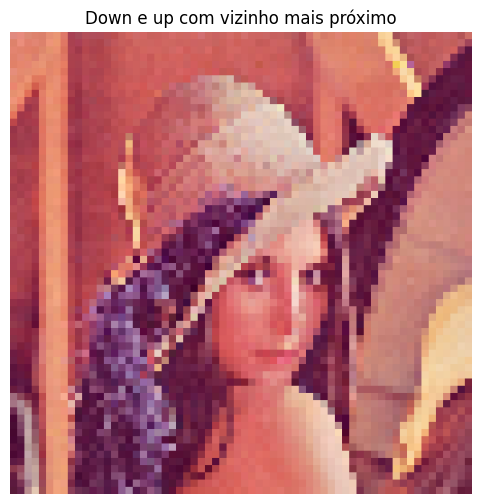

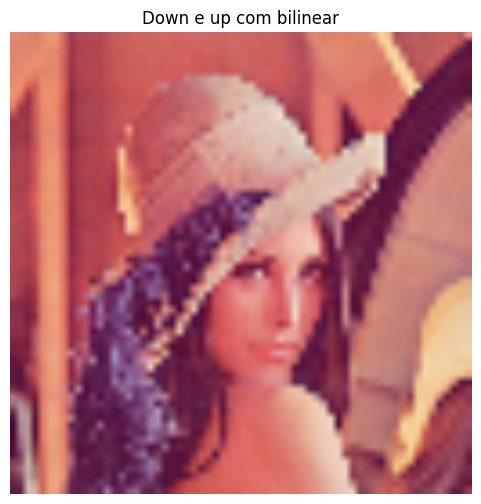

Submatriz 5x5:
 [[ 98 111 116 112 117]
 [ 97 101 107 109 100]
 [ 96  98 101  99 103]
 [ 89  73  72  74  85]
 [ 71  75  56  54  62]]


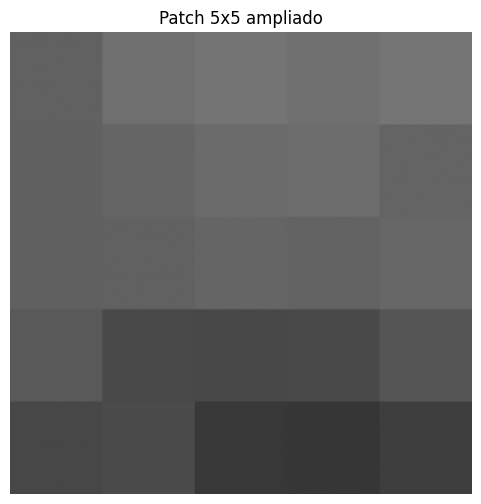

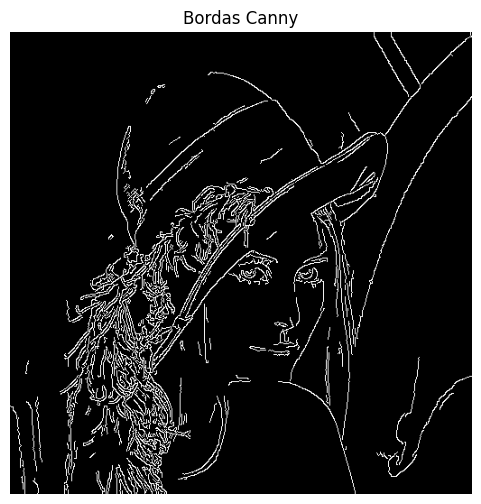

In [ ]:
# Bloco 1: setup e carregamento da Lena
import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlretrieve
import os

url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
img_path = "lena.jpg"
if not os.path.exists(img_path):
    urlretrieve(url, img_path)

img_bgr = cv2.imread(img_path)               # BGR no OpenCV
if img_bgr is None:
    raise RuntimeError("Falha ao carregar a imagem.")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

print("Dimensões RGB:", img_rgb.shape)       # (altura, largura, canais)

# Função utilitária para exibir imagem
def show(title, image, is_gray=False):
    plt.figure(figsize=(6,6))
    if is_gray:
        plt.imshow(image, cmap="gray", vmin=0, vmax=255)
    else:
        plt.imshow(image)
    plt.title(title)
    plt.axis("off")
    plt.show()

show("Original RGB", img_rgb)
show("Tons de cinza 8 bits", img_gray, is_gray=True)

# Bloco 2: quantização em níveis de cinza
def quantize_gray(img_gray, levels):
    q = np.floor(img_gray.astype(np.float32) * levels / 256.0)
    q = np.clip(q, 0, levels - 1).astype(np.uint8)
    if levels > 1:
        out = (q * (255 // (levels - 1))).astype(np.uint8)
    else:
        out = (q * 255).astype(np.uint8)
    return out

for lv in [2, 4, 16, 256]:
    qimg = quantize_gray(img_gray, lv)
    show(f"Quantização cinza: {lv} níveis", qimg, is_gray=True)

# Bloco 3: quantização por canal RGB
def quantize_rgb(img_rgb, levels_per_channel):
    x = img_rgb.astype(np.float32)
    q = np.floor(x * (levels_per_channel / 256.0))
    q = np.clip(q, 0, levels_per_channel - 1)
    if levels_per_channel > 1:
        out = (q * (255 // (levels_per_channel - 1))).astype(np.uint8)
    else:
        out = (q * 255).astype(np.uint8)
    return out

for lv in [2, 4, 8, 16]:
    qimg_rgb = quantize_rgb(img_rgb, lv)
    show(f"Quantização RGB por canal: {lv} níveis", qimg_rgb)

# Bloco 4: amostragem e aliasing com e sem pré-filtro
def down_up(img, factor, pre_blur=False):
    x = img
    if pre_blur:
        k = max(3, int(2*factor + 1))
        x = cv2.GaussianBlur(x, (k, k), sigmaX=0)
    h, w = x.shape[:2]
    small = cv2.resize(x, (w//factor, h//factor), interpolation=cv2.INTER_NEAREST)
    up = cv2.resize(small, (w, h), interpolation=cv2.INTER_NEAREST)
    return up

for f in [2, 4, 8]:
    up_no_blur = down_up(img_rgb, f, pre_blur=False)
    up_blur = down_up(img_rgb, f, pre_blur=True)
    show(f"Subamostragem x{f} sem pré-filtro", up_no_blur)
    show(f"Subamostragem x{f} com pré-filtro gaussiano", up_blur)

# Bloco 5: inversão de cores
inv_rgb = 255 - img_rgb
inv_gray = 255 - img_gray
show("Inversão de cor RGB", inv_rgb)
show("Inversão de cinza", inv_gray, is_gray=True)

# Bloco 6: brilho e contraste
# Fórmula do OpenCV: out = alpha * img + beta com saturação em [0,255]
def adjust_brightness_contrast(img, alpha=1.2, beta=30):
    return cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

bc1 = adjust_brightness_contrast(img_rgb, alpha=1.2, beta=30)
bc2 = adjust_brightness_contrast(img_rgb, alpha=0.8, beta=-30)
show("Brilho/contraste alpha 1.2 beta 30", bc1)
show("Brilho/contraste alpha 0.8 beta -30", bc2)

# Bloco 7: limiarização (threshold) fixo e Otsu
_, th_bin = cv2.threshold(img_gray, 128, 255, cv2.THRESH_BINARY)
show("Threshold fixo 128", th_bin, is_gray=True)

_, th_otsu = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
show("Threshold Otsu automático", th_otsu, is_gray=True)

# Bloco 8: comparação de reamostragem vizinho mais próximo e bilinear
def resize_compare(img, new_w):
    h, w = img.shape[:2]
    new_h = int(h * new_w / w)
    small_nn = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_NEAREST)
    big_nn = cv2.resize(small_nn, (w, h), interpolation=cv2.INTER_NEAREST)
    small_bl = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    big_bl = cv2.resize(small_bl, (w, h), interpolation=cv2.INTER_LINEAR)
    return big_nn, big_bl

big_nn, big_bl = resize_compare(img_rgb, new_w=64)
show("Down e up com vizinho mais próximo", big_nn)
show("Down e up com bilinear", big_bl)

# Bloco 9: patch 5x5 para matriz de exercício
cy, cx = img_gray.shape[0] // 2, img_gray.shape[1] // 2
half = 2
patch = img_gray[cy-half:cy+half+1, cx-half:cx+half+1]
print("Submatriz 5x5:\n", patch)
patch_zoom = cv2.resize(patch, (patch.shape[1]*40, patch.shape[0]*40), interpolation=cv2.INTER_NEAREST)
show("Patch 5x5 ampliado", patch_zoom, is_gray=True)

# Bloco 10: extra opcional bordas com Canny
edges = cv2.Canny(img_gray, 100, 200)
show("Bordas Canny", edges, is_gray=True)